In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("/content/drive/MyDrive/NLP/train.csv")

print(df.shape)
df.head()

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


Basic Overview

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


Target distribution (duplicate vs non-duplicate)

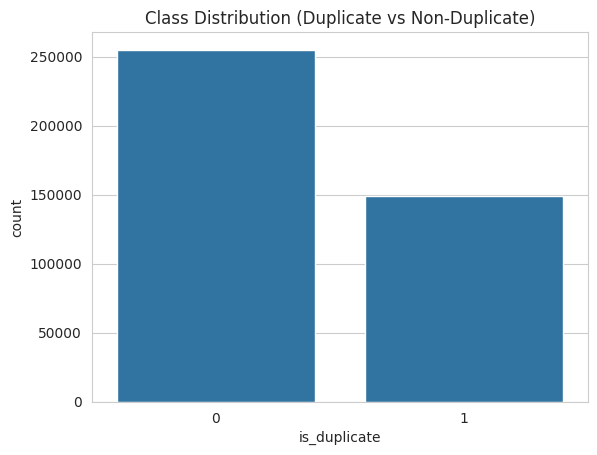

is_duplicate
0    0.630802
1    0.369198
Name: proportion, dtype: float64


In [6]:
sns.countplot(x='is_duplicate', data=df)
plt.title("Class Distribution (Duplicate vs Non-Duplicate)")
plt.show()

print(df['is_duplicate'].value_counts(normalize=True))

Text length features

In [7]:
df['q1_len'] = df['question1'].astype(str).apply(len)
df['q2_len'] = df['question2'].astype(str).apply(len)

df['q1_word_count'] = df['question1'].astype(str).apply(lambda x: len(x.split()))
df['q2_word_count'] = df['question2'].astype(str).apply(lambda x: len(x.split()))

Length Distribution

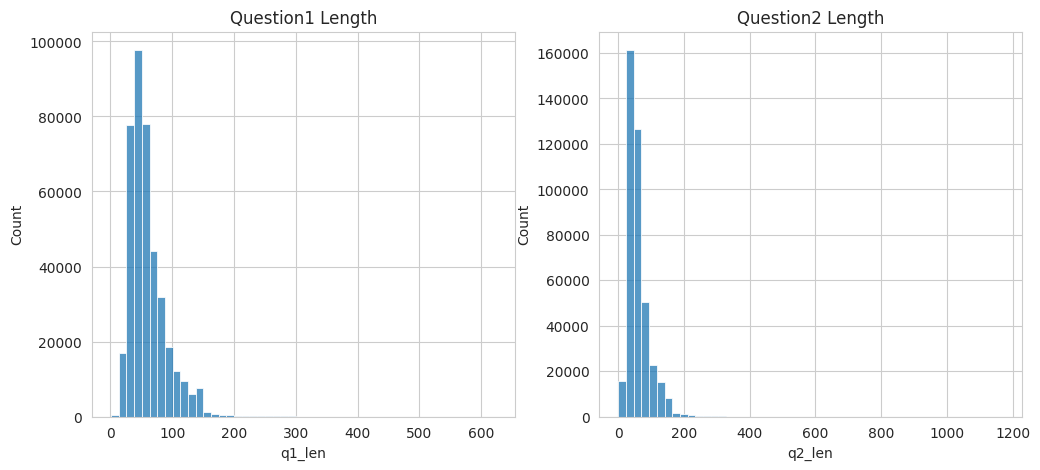

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['q1_len'], bins=50, ax=axes[0])
axes[0].set_title("Question1 Length")

sns.histplot(df['q2_len'], bins=50, ax=axes[1])
axes[1].set_title("Question2 Length")

plt.show()

Duplicate vs non-duplicate comparison

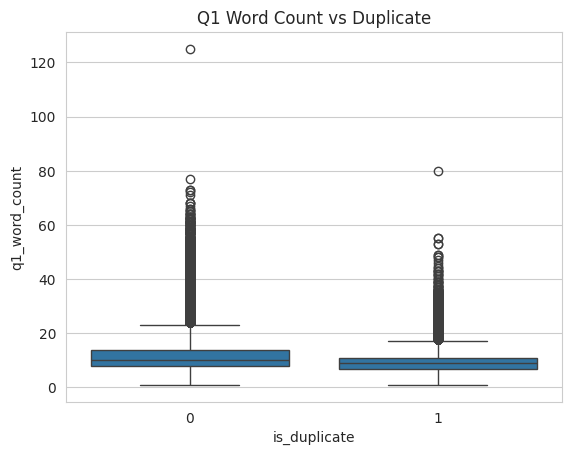

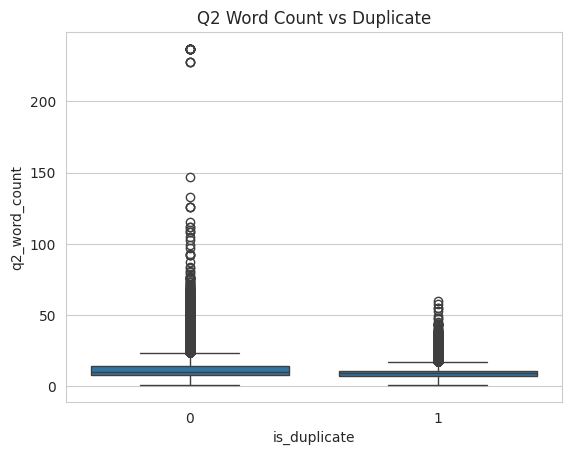

In [9]:
sns.boxplot(x='is_duplicate', y='q1_word_count', data=df)
plt.title("Q1 Word Count vs Duplicate")
plt.show()

sns.boxplot(x='is_duplicate', y='q2_word_count', data=df)
plt.title("Q2 Word Count vs Duplicate")
plt.show()

Common words analysis

In [18]:
from collections import Counter

def get_top_words(series, n=20):
    all_words = " ".join(series.astype(str)).lower().split()
    return Counter(all_words).most_common(n)

top_words = get_top_words(df['question1'])
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])
top_words_df.head(10)

,word,count
0,the,188263
1,what,156580
2,is,133740
3,how,108685
4,a,101150
5,i,101108
6,to,98192
7,in,96820
8,of,79491
9,do,75887


Word overlap feature

In [11]:
def word_overlap(q1, q2):
    q1_words = set(str(q1).lower().split())
    q2_words = set(str(q2).lower().split())
    if len(q1_words) == 0 or len(q2_words) == 0:
        return 0
    return len(q1_words & q2_words) / len(q1_words | q2_words)

df['word_overlap'] = df.apply(lambda row: word_overlap(row['question1'], row['question2']), axis=1)

Overlap vs duplicate

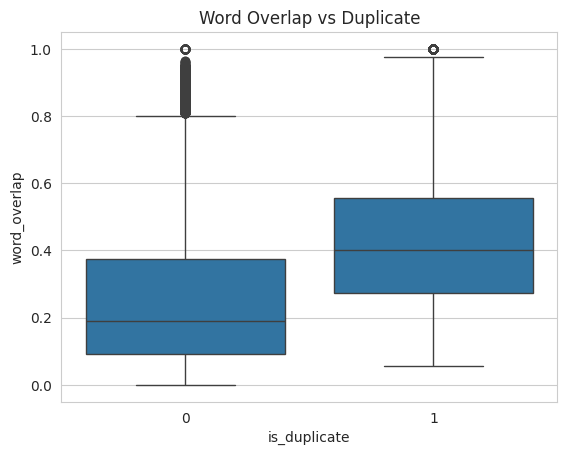

In [12]:
sns.boxplot(x='is_duplicate', y='word_overlap', data=df)
plt.title("Word Overlap vs Duplicate")
plt.show()

Correlation heatmap

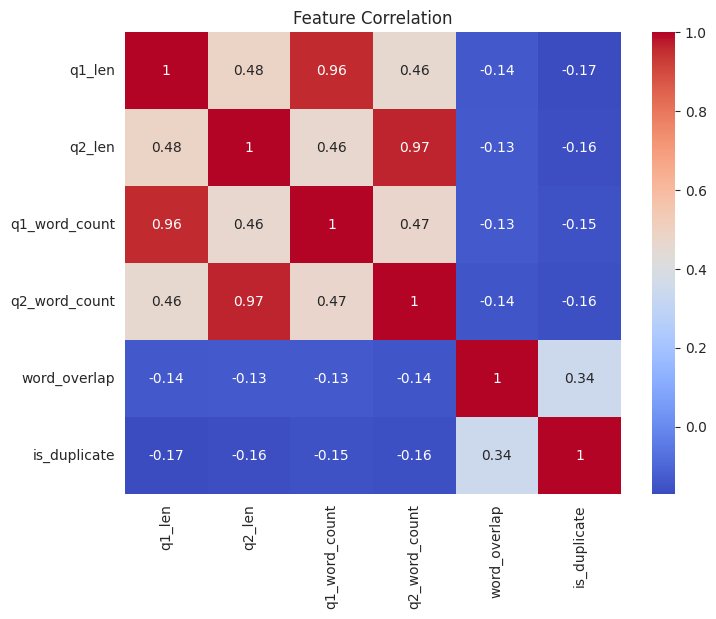

In [13]:
features = ['q1_len', 'q2_len', 'q1_word_count', 'q2_word_count', 'word_overlap']

corr = df[features + ['is_duplicate']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Duplicate question ids

In [14]:
print(df['qid1'].duplicated().sum())
print(df['qid2'].duplicated().sum())

113636
104926


Missing / empty questions

In [23]:
df[df['question1'].isnull()]

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_word_count,q2_word_count,word_overlap
363362,363362,493340,493341,NaN,My Chinese name is Haichao Yu. What English na...,0,3,123,1,21,0.0


In [22]:
df[df['question2'].isnull()]

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_word_count,q2_word_count,word_overlap
105780,105780,174363,174364,How can I develop android app?,NaN,0,30,3,6,1,0.0
201841,201841,303951,174364,How can I create an Android app?,NaN,0,32,3,7,1,0.0
